In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [2]:
# !rm -rf '/content/data'
# !rm -rf '/content/metadata'
# !rm -rf '/content/set'
# !rm -rf '/content/set_unseen'
# !rm -rf '/content/classification_model.h5'
# !rm -rf '/content/complete_xray_features.csv'
# !rm -rf '/content/min_max_scaler_file.pkl'

In [1]:
# To unzip
from zipfile import ZipFile
file_name = "/content/drive/MyDrive/Colab Notebooks/Dataset/ZSL_set.zip"
with ZipFile(file_name, 'r') as zip:
  zip.extractall()
  print(f'done! {file_name}')

file_name = "/content/drive/MyDrive/Colab Notebooks/Dataset/ZSL_set_unseen.zip"
with ZipFile(file_name, 'r') as zip:
  zip.extractall()
  print(f'done! {file_name}')

done! /content/drive/MyDrive/Colab Notebooks/Dataset/ZSL_set.zip
done! /content/drive/MyDrive/Colab Notebooks/Dataset/ZSL_set_unseen.zip


In [2]:
!pip install split-folders

import splitfolders
splitfolders.ratio('set', output="data", seed=42, ratio=(0.8, 0.1, 0.1))

Copying files: 11658 files [01:00, 192.28 files/s]


In [4]:
# libs
import numpy as np
import pandas as pd
import os
from tqdm import tqdm
from PIL import Image
import glob

import tensorflow as tf
import keras
from keras.applications import ResNet50
from keras.applications.resnet50 import preprocess_input
from keras.models import Model, load_model
from keras.layers import Input, Dense, Concatenate, Flatten, Dropout, BatchNormalization
from keras.optimizers import Adam

import cv2
# from skimage.feature import greycomatrix, greycoprops
from skimage.feature import graycomatrix, graycoprops

import builtins
zip = builtins.zip   # restore the real zip function

from pickle import dump , load

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

# confusion matrix
from sklearn.metrics import confusion_matrix
# accuracy: (tp + tn) / (p + n)
from sklearn.metrics import accuracy_score
# classification_report
from sklearn.metrics import classification_report
# kappa
from sklearn.metrics import cohen_kappa_score

from sentence_transformers import SentenceTransformer, util
import torch

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# !pip install h5py
import h5py

import warnings
warnings.filterwarnings('ignore')

In [5]:
# function

ResNet50_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')
# Function to extract visual features using ResNet50
def extract_visual_features(image_path):
    img = Image.open(image_path).convert("RGB")
    # print(f'img: {img}')
    img = img.resize((224, 224))  # Resize image for ResNet50 input
    # print(f'img: {img}')
    img_array = np.array(img)
    # print(f'img_array: {img_array}')
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    # print(f'img_array: {img_array}')
    img_array = preprocess_input(img_array)
    # print(f'img_array: {img_array}')

    # ResNet50_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')
    visual_features = ResNet50_model.predict(img_array, verbose = 0)
    # print(f'visual_features : {visual_features}')

    return visual_features

# Function to compute GLCM texture features
def compute_texture_features(image_path):
    # from skimage.feature import graycomatrix, graycoprops

    # Define your GLCM properties (distances and angles)
    distances = [1, 3, 5, 3, 1, 3, 5]
    angles = [0, 0, 0, np.pi/4, np.pi/2, np.pi/2, np.pi/2]

    glcm_features = []
    for distance, angle in list(zip(distances, angles)):
        img_gray = Image.open(image_path).convert('L')  # Convert image to grayscale
        img_gray_array = np.array(img_gray)

        # Compute GLCM properties
        glcm = graycomatrix(img_gray_array,
                            distances=[distance],
                            angles=[angle],
                            levels=256,
                            symmetric=True,
                            normed=True)
        contrast = graycoprops(glcm, 'contrast')[0, 0]
        dissimilarity = graycoprops(glcm, 'dissimilarity')[0, 0]
        homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
        energy = graycoprops(glcm, 'energy')[0, 0]
        correlation = graycoprops(glcm, 'correlation')[0, 0]

        glcm_features.extend([contrast, dissimilarity, homogeneity, energy, correlation])

    return np.array(glcm_features) # np.array([contrast, dissimilarity, homogeneity, energy, correlation])

# Load image data and compute features
def load_data_and_compute_features(data_dir):
    visual_features = []
    texture_features = []
    labels = []

    classes = sorted(os.listdir(data_dir))
    class_to_index = {cls: idx for idx, cls in enumerate(classes)}
    # print(f"classes : {classes} \nclass_to_index : {class_to_index}")

    for cls in tqdm(classes, desc="Processing images"):
    # for cls in classes:
        cls_dir = os.path.join(data_dir, cls)
        # print(f'cls_dir : {cls_dir}')

        for img_name in os.listdir(cls_dir):
            img_path = os.path.join(cls_dir, img_name)
            # print(f'img_path : {img_path}')

            # Extract visual features using ResNet50
            visual_feat = extract_visual_features(img_path)
            visual_features.append(visual_feat)
            # print(f"visual_features : {visual_features}")

            # Compute texture features using GLCM
            texture_feat = compute_texture_features(img_path)
            texture_features.append(texture_feat)
            # print(f"texture_features : {texture_features}")

            # Assign label index
            labels.append(class_to_index[cls])
            # print(f"img_path : {img_path} || labels : {class_to_index[cls]} \n")
            # print(f"texture_features : {texture_feat} \n")

    visual_features = np.array(visual_features)
    texture_features = np.array(texture_features)
    labels = np.array(labels)

    return visual_features, texture_features, labels


# load_data_and_compute_features
data_directory = '/content/data/train'
visual_features, texture_features, labels = load_data_and_compute_features(data_directory)
print('Done')
print(visual_features.shape, texture_features.shape, labels.shape)
'''
Note: It will take 20:31 mins.
'''

data_vt = pd.DataFrame(np.concatenate([visual_features.reshape(visual_features.shape[0], -1), texture_features], axis=1))
data_vt['labels'] = labels

data_vt.to_csv('complete_xray_features.csv', index=False)
'''
Note: Download 'complete_xray_features.csv' file for reuse.
'''


Processing images: 100%|██████████| 7/7 [57:34<00:00, 493.50s/it]


Done
(9325, 1, 2048) (9325, 35) (9325,)


"\nNote: Download 'complete_xray_features.csv' file for reuse.\n"

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2083)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       266,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 267,655 (1.02 MB)

 Trainable params: 267,655 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.2466 - loss: 2.1147 - val_accuracy: 0.2949 - val_loss: 1.9203
Epoch 2/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4745 - loss: 1.3749 - val_accuracy: 0.2902 - val_loss: 1.8802
Epoch 3/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5917 - loss: 1.1245 - val_accuracy: 0.3027 - val_loss: 1.9306
Epoch 4/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.7092 - loss: 0.9019 - val_accuracy: 0.3091 - val_loss: 2.0067
Epoch 5/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7797 - loss: 0.7403 - val_accuracy: 0.2895 - val_loss: 2.0655
Epoch 6/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8456 - loss: 0.5959 - val_accuracy: 0.2898 - val_loss: 2.1409
Epoch 7/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8915 - loss: 0.4932 - val_accuracy: 0.2820 - val_loss: 2.1912
Epoch 8/100
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9205 - loss: 0.3982 - val

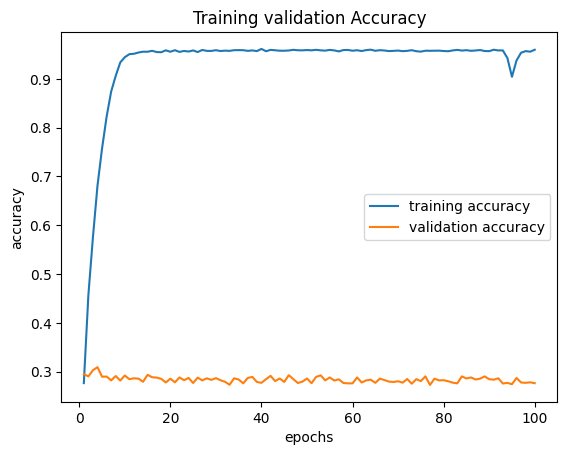

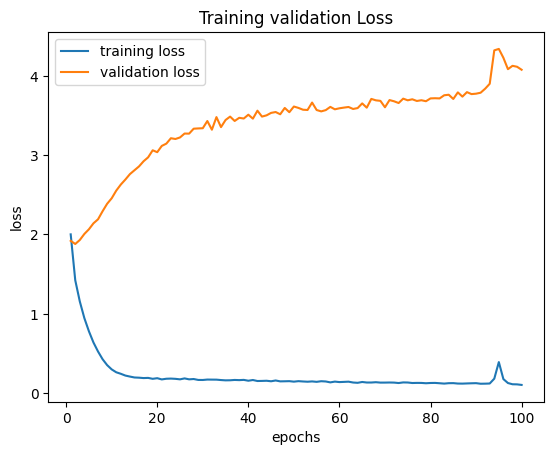

classification_model : <Functional name=functional, built=True> 

Saved model to disk


In [6]:
# Variable's
min_max_scaler_file = 'min_max_scaler_file.pkl'

# Function
# Build and train a classification model
def build_and_train_model(visual_features, texture_features, labels):
    # Concatenate visual and texture features
    combined_features = np.concatenate([visual_features,
                                        texture_features],
                                       axis=1)

    # Normalize the features
    min_max_scaler = StandardScaler()
    train_normalized_texture_features = min_max_scaler.fit_transform(combined_features)
    train_normalized_texture_features_df = pd.DataFrame(train_normalized_texture_features)

    # save
    dump(min_max_scaler, open(min_max_scaler_file, 'wb'))

    # Split data into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(train_normalized_texture_features_df,
                                                        labels,
                                                        test_size=0.3,
                                                        random_state=42,
                                                        stratify=labels)

    # Define classification model
    input_layer = Input(shape=(combined_features.shape[1],))
    # hidden_layer = Dense(1024, activation='relu')(input_layer)
    # hidden_layer = Dense(512, activation='relu')(hidden_layer)
    # hidden_layer = Dense(256, activation='relu')(hidden_layer)
    hidden_layer = Dense(128, activation='relu')(input_layer)
    # hidden_layer = Dense(64, activation='relu')(hidden_layer)
    # hidden_layer = Dense(32, activation='relu')(hidden_layer)
    output_layer = Dense(len(np.unique(labels)), activation='softmax')(hidden_layer)
    model = Model(inputs=input_layer, outputs=output_layer)

    # input_layer = Input(shape=(combined_features.shape[1],))

    # x = Dense(1024, activation='relu', kernel_regularizer='l2')(input_layer)
    # x = BatchNormalization()(x)
    # x = Dropout(0.3)(x)

    # x = Dense(512, activation='relu', kernel_regularizer='l2')(x)
    # x = BatchNormalization()(x)
    # x = Dropout(0.3)(x)

    # x = Dense(256, activation='relu')(x)
    # x = Dropout(0.2)(x)

    # x = Dense(256, activation='relu')(x)
    # x = Dropout(0.2)(x)

    # x = Dense(128, activation='relu')(input_layer)
    # x = Dense(64, activation='relu')(x)
    # x = Dense(32, activation='relu')(x)

    # output_layer = Dense(len(np.unique(labels)), activation='softmax')(x)

    # model = Model(inputs=input_layer, outputs=output_layer)

    model.compile(optimizer=Adam(learning_rate=0.0005),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    model.summary()

    # Train the model
    history = model.fit(X_train, y_train,
                        epochs=100,
                        batch_size=64,
                        validation_data=(X_test, y_test))

    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']

    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(1, len(acc)+1)

    plt.plot(epochs, acc, label='training accuracy')
    plt.plot(epochs, val_acc, label='validation accuracy')
    plt.legend()
    plt.xlabel('epochs')
    plt.ylabel('accuracy')
    plt.title('Training validation Accuracy')
    plt.show()

    plt.plot(epochs, loss, label='training loss')
    plt.plot(epochs, val_loss, label='validation loss')
    plt.legend()
    plt.xlabel('epochs')
    plt.ylabel('loss')
    plt.title('Training validation Loss')
    plt.show()

    return model

# load csv
data_vtl = pd.read_csv('/content/complete_xray_features.csv')
visual_features, texture_features, labels = data_vtl.iloc[:,:2048], data_vtl.iloc[:,2048:-1], data_vtl.iloc[:,-1]

# Build and train the classification model
classification_model = build_and_train_model(visual_features, texture_features, labels)
print(f'classification_model : {classification_model} \n')

# save model and architecture to single file
classification_model.save("classification_model.h5")
print("Saved model to disk")

,image_path,image_label,pred_image_label,act_label,pred_label
0,/content/data/test/Consolidation/00013608_002.png,Consolidation,Consolidation,1,1
1,/content/data/test/Consolidation/00016778_045.png,Consolidation,Atelectasis,1,0


Accuracy: 25.43 %
Log Loss: 74.57 %
Cohen's Kappa Score: 10.69 %

classification_report:
              precision    recall  f1-score   support

           0       0.25      0.31      0.28       200
           1       0.21      0.23      0.22       200
           2       0.24      0.27      0.25       200
           3       0.15      0.08      0.11        24
           4       0.30      0.28      0.29       200
           5       0.35      0.31      0.33       200
           6       0.15      0.11      0.13       144

    accuracy                           0.25      1168
   macro avg       0.24      0.23      0.23      1168
weighted avg       0.25      0.25      0.25      1168



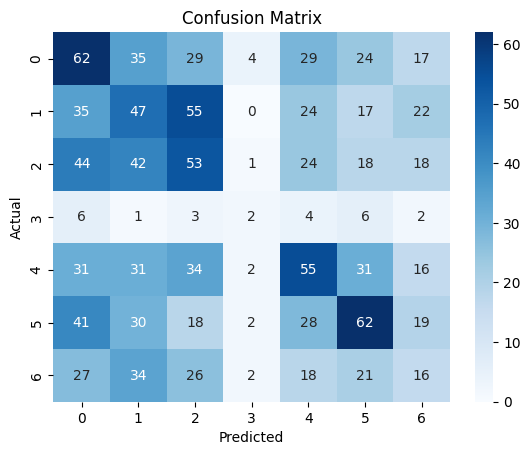

In [7]:
# model evaluation
def evaluate_model(test_labels, pred_labels):
    '''
    This function is use to model evaluation.

    Input:
    test_labels : Actual test lebels.
    pred_labels : Predicted labels.

    Output: None

    '''
    # Accuracy
    acc = accuracy_score(test_labels, pred_labels)

    # Log loss
    loss = 1 - acc

    # Cohen's Kappa Score
    kappa = cohen_kappa_score(test_labels, pred_labels)

    # Print results
    print(f"Accuracy: {acc*100:.2f} %")
    print(f"Log Loss: {loss*100:.2f} %")
    print(f"Cohen's Kappa Score: {kappa*100:.2f} %\n")
    print("classification_report:")
    print(classification_report(test_labels, pred_labels))

    # Confusion Matrix
    cm = confusion_matrix(test_labels, pred_labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


# classification report without transformer
# Load models
classification_model = load_model(r'/content/classification_model.h5')
min_max_scaler_model = load(open(r'/content/min_max_scaler_file.pkl', 'rb'))
class_labels = ['Atelectasis', 'Consolidation', 'Effusion', 'Hernia',
                'Mass', 'No Finding', 'Pneumonia']

'''
Note : Added way to read the folde images one by one.
'''
# i=0
# folder_name = 'bobcat'
# folder_path = os.path.join('drive','MyDrive','AWA2-daatset','train classes', folder_name, '*')
# print(folder_path)
# for img_path in glob.glob(folder_path):
#     i = i+1
#     print(img_path)
# print(i)

image_path, image_label, pred_image_label, act_label, pred_label = [], [], [], [], []
# i = 0
for img_path in glob.glob(r"/content/data/test/*/*"):
# for img_path in glob.glob(folder_path):
    # print(f"img_path : {img_path}")
    image_path.append(img_path)
    image_label.append(img_path.split('/')[-2])
    act_label.append(class_labels.index(img_path.split('/')[-2]))

    # Extract visual features using ResNet50
    visual_features = extract_visual_features(img_path)
    # print(f"visual_features : {visual_features.shape} || {type(visual_features)}")

    # Compute texture features using GLCM
    texture_features = compute_texture_features(img_path)
    # print(f"texture_feat : {texture_features.shape} || {type(texture_features)}")

    # Concatenate visual and texture features
    l1 = visual_features[0].tolist()
    l2 = texture_features.tolist()
    l1.extend(l2)
    combined_features = np.array(l1)
    # print(f"combined_features : {combined_features}")

    # Normalize the features
    train_normalized_texture_features = min_max_scaler_model.transform([combined_features])
    train_normalized_texture_features_df = pd.DataFrame(train_normalized_texture_features)
    # print(f"train_normalized_texture_features_df : {train_normalized_texture_features_df}")

    # model predict
    predicted_value = classification_model.predict(train_normalized_texture_features_df, verbose = 0)
    # print(f"predicted_value : {np.argmax(predicted_value)} || {class_labels[np.argmax(predicted_value)]}")
    pred_image_label.append(class_labels[np.argmax(predicted_value)])
    pred_label.append(np.argmax(predicted_value))

    # i=i+1
    # if (i==10):
    #   break

out_df = pd.DataFrame({
    'image_path' : image_path,
    'image_label' : image_label,
    'pred_image_label' : pred_image_label,
    'act_label' : act_label,
    'pred_label' : pred_label
})
display(out_df.head(2))

metadata_folder_name = 'metadata'
os.makedirs(metadata_folder_name, exist_ok=True)
# metadata_file_name = os.path.join(metadata_folder_name, folder_name + '_resnet50_result.csv')
metadata_file_name = os.path.join(metadata_folder_name, 'resnet50_result_classification report without transformer.csv')
out_df.to_csv(metadata_file_name, index = False)


'''
Note : Run only after compliting all classes to combine
'''
# metadata_file_name = os.path.join(metadata_folder_name, '*')
# df_list = [pd.read_csv(df_path) for df_path in glob.glob(metadata_file_name)]
# out_df = pd.concat(df_list).reset_index(drop=True)
# out_df

# classification report
true_labels = out_df['act_label']
predicted_labels = out_df['pred_label']
evaluate_model(true_labels, predicted_labels)

# matrix = confusion_matrix(true_labels, predicted_labels)
# print(matrix, '\n')

# accuracy = accuracy_score(true_labels, predicted_labels)
# print('Accuracy: %f' % accuracy, '\n')
# print('Error rate: %f' % (1-accuracy), '\n')

# # Generate classification report
# report = classification_report(true_labels, predicted_labels)
# print(report, '\n')

# kappa = cohen_kappa_score(true_labels, predicted_labels)
# print('Cohens kappa: %f' % kappa)

# # Commented out IPython magic to ensure Python compatibility.
# plt.rcParams['font.size'] = 8
# bg_color = (0, 0.77, 0.77)
# plt.rcParams['figure.facecolor'] = bg_color
# plt.rcParams['axes.facecolor'] = bg_color

# fig, ax = plt.subplots(1)

# plt.text(1, -.3, "Confusion Matrix", fontsize = 18, color='Black', fontstyle='italic')

# ax = sns.heatmap(matrix, annot=True, annot_kws={'size':6}, fmt="d",
#                  robust=True, linewidths=.9, cmap="RdYlBu", square=True)
# # vmin=0, vmax=350,
# plt.savefig("Confusion_Matrix.jpeg", dpi=300, facecolor=bg_color, transparent=True)
# plt.show()

In [9]:
display(out_df.head())

,image_path,image_label,pred_image_label,act_label,pred_label
0,/content/data/test/Consolidation/00013608_002.png,Consolidation,Consolidation,1,1
1,/content/data/test/Consolidation/00016778_045.png,Consolidation,Atelectasis,1,0
2,/content/data/test/Consolidation/00006741_008.png,Consolidation,Mass,1,4
3,/content/data/test/Consolidation/00018778_004.png,Consolidation,Consolidation,1,1
4,/content/data/test/Consolidation/00020471_003.png,Consolidation,Mass,1,4


In [10]:
SentenceTransformer_model = SentenceTransformer('all-MiniLM-L6-v2')

img_dir = r'/content/data/train/*' # os.path.join('content', 'data', 'train', '*')
image_class = sorted([path.split('/')[-1] for path in glob.glob(img_dir)])
idx_to_class = {k: v for k, v in enumerate(image_class)}
# print(f'idx_to_class : {idx_to_class}')

words = list(idx_to_class.values())
embeddings = SentenceTransformer_model.encode(words, convert_to_tensor=True)
# print(f'words : {words}')
# print(f'embeddings : {embeddings}')

similar_wds = []
for _, row in out_df.iterrows():
    # print(row['pred_image_label'])
    # Find top n similar
    query = SentenceTransformer_model.encode(row['pred_image_label'], convert_to_tensor=True)
    cosine_scores = util.cos_sim(query, embeddings)

    # Show top-3 results
    top_results = torch.topk(cosine_scores[0], k=5)
    wds, cos_scores = [], []
    for idx in top_results.indices:
        # print(words[idx], float(cosine_scores[0][idx]))
        wds.append(words[idx])
        cos_scores.append(round(float(cosine_scores[0][idx])*100,2))
    similar_wds.append((wds, cos_scores))

out_df['similar_wds'] = similar_wds
display(out_df.head())

with_transformer_file_name = os.path.join(metadata_folder_name, 'resnet50_result_classification report with transformer.csv')
out_df.to_csv(with_transformer_file_name, index=False)
print(f'Done! {with_transformer_file_name} File saved.  \n')


,image_path,image_label,pred_image_label,act_label,pred_label,similar_wds
0,/content/data/test/Consolidation/00013608_002.png,Consolidation,Consolidation,1,1,"([Consolidation, Effusion, Hernia, Mass, Pneum..."
1,/content/data/test/Consolidation/00016778_045.png,Consolidation,Atelectasis,1,0,"([Atelectasis, Effusion, Hernia, Pneumonia, Ma..."
2,/content/data/test/Consolidation/00006741_008.png,Consolidation,Mass,1,4,"([Mass, Effusion, No Finding, Hernia, Consolid..."
3,/content/data/test/Consolidation/00018778_004.png,Consolidation,Consolidation,1,1,"([Consolidation, Effusion, Hernia, Mass, Pneum..."
4,/content/data/test/Consolidation/00020471_003.png,Consolidation,Mass,1,4,"([Mass, Effusion, No Finding, Hernia, Consolid..."


Done! metadata/resnet50_result_classification report with transformer.csv File saved.  



Accuracy: 73.46 %
Log Loss: 26.54 %
Cohen's Kappa Score: 68.32 %

classification_report:
              precision    recall  f1-score   support

           0       0.64      0.68      0.66       200
           1       0.66      0.63      0.64       200
           2       0.81      0.91      0.85       200
           3       0.92      1.00      0.96        24
           4       0.81      1.00      0.89       200
           5       0.72      0.45      0.55       200
           6       0.71      0.69      0.70       144

    accuracy                           0.73      1168
   macro avg       0.75      0.77      0.75      1168
weighted avg       0.73      0.73      0.72      1168



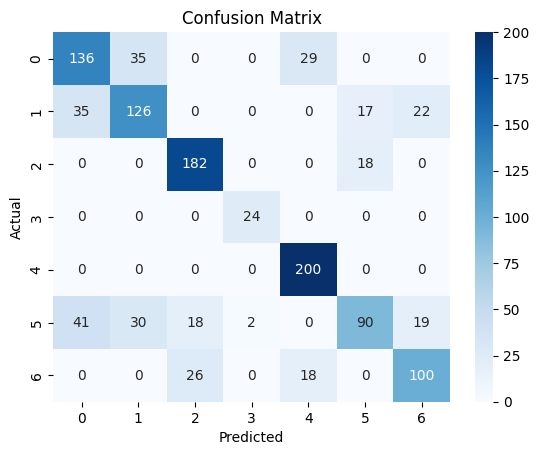

--------------------------------------------------  END  -------------------------------------------------- 



In [11]:
df = pd.read_csv(with_transformer_file_name)
zsl_classes, unseen_class = [], []

for _, row in df.iterrows():
    ActualClass = row['image_label']
    SimilarWords = eval(row['similar_wds'])[0]

    if ActualClass in SimilarWords:
        zsl_classes.append(words.index(ActualClass))
        unseen_class.append(words.index(ActualClass))
    else:
        zsl_classes.append(words.index(SimilarWords[0]))
        unseen_class.append(words.index(ActualClass))

df['ZSL Predicted Class'] = zsl_classes
df['ZSL Unseen Class'] = unseen_class
# display(df.head())

test_labels, pred_labels = df['ZSL Unseen Class'], df['ZSL Predicted Class']
evaluate_model(test_labels, pred_labels)

df.to_csv(with_transformer_file_name, index=False)
print('-'*50, ' END ', '-'*50, '\n')

,image_path,image_label,pred_image_label,act_label,pred_label
0,/content/set_unseen/Infiltration/00027700_005.png,Infiltration,Infiltration,4,4
1,/content/set_unseen/Infiltration/00010062_000.png,Infiltration,Nodule,4,5


Accuracy: 14.97 %
Log Loss: 85.02 %
Cohen's Kappa Score: 2.83 %

classification_report:
              precision    recall  f1-score   support

           0       0.14      0.21      0.17       500
           1       0.19      0.28      0.23       500
           2       0.14      0.17      0.15       500
           3       0.25      0.03      0.05       500
           4       0.12      0.16      0.14       500
           5       0.18      0.24      0.20       500
           6       0.10      0.10      0.10       500
           7       0.00      0.00      0.00       500

    accuracy                           0.15      4000
   macro avg       0.14      0.15      0.13      4000
weighted avg       0.14      0.15      0.13      4000



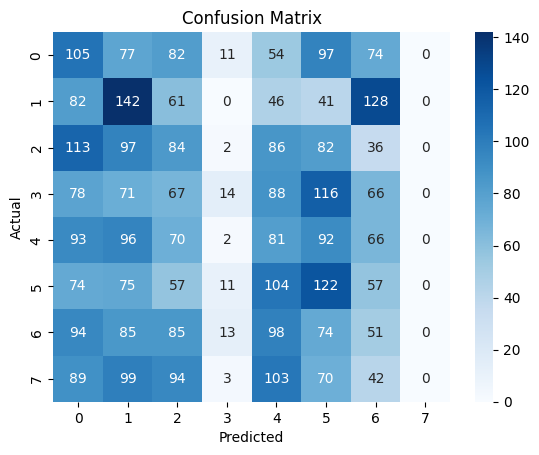

In [17]:
# With Unseen Dataset

# Load models
classification_model = load_model(r'/content/classification_model.h5')
min_max_scaler_model = load(open(r'/content/min_max_scaler_file.pkl', 'rb'))
class_labels = ['Cardiomegaly', 'Edema', 'Emphysema', 'Fibrosis', 'Infiltration',
                'Nodule', 'Pleural_Thickening', 'Pneumothorax']

# Feature Extractor
image_path, image_label, pred_image_label, act_label, pred_label = [], [], [], [], []

for img_path in glob.glob(r'/content/set_unseen/*/*'):
    # print(f"img_path : {img_path}")
    image_path.append(img_path)
    image_label.append(img_path.split('/')[-2])
    act_label.append(class_labels.index(img_path.split('/')[-2]))

    # Extract visual features using ResNet50
    visual_features = extract_visual_features(img_path)
    # print(f"visual_features : {visual_features.shape} || {type(visual_features)}")

    # Compute texture features using GLCM
    texture_features = compute_texture_features(img_path)
    # print(f"texture_feat : {texture_features.shape} || {type(texture_features)}")

    # Concatenate visual and texture features
    l1 = visual_features[0].tolist()
    l2 = texture_features.tolist()
    l1.extend(l2)
    combined_features = np.array(l1)
    # print(f"combined_features : {combined_features}")

    # Normalize the features
    train_normalized_texture_features = min_max_scaler_model.transform([combined_features])
    train_normalized_texture_features_df = pd.DataFrame(train_normalized_texture_features)
    # print(f"train_normalized_texture_features_df : {train_normalized_texture_features_df}")

    # model predict
    predicted_value = classification_model.predict(train_normalized_texture_features_df, verbose = 0)
    # print(f"predicted_value : {np.argmax(predicted_value)} || {class_labels[np.argmax(predicted_value)]}")
    pred_image_label.append(class_labels[np.argmax(predicted_value)])
    pred_label.append(np.argmax(predicted_value))

out_df = pd.DataFrame({
    'image_path' : image_path,
    'image_label' : image_label,
    'pred_image_label' : pred_image_label,
    'act_label' : act_label,
    'pred_label' : pred_label
})
display(out_df.head(2))

metadata_folder_name = 'metadata'
os.makedirs(metadata_folder_name, exist_ok=True)
metadata_file_name = os.path.join(metadata_folder_name, 'resnet50_result_classification report without transformer_unseen.csv')
out_df.to_csv(metadata_file_name, index = False)

# classification report
true_labels = out_df['act_label']
predicted_labels = out_df['pred_label']
evaluate_model(true_labels, predicted_labels)


In [18]:
SentenceTransformer_model = SentenceTransformer('all-MiniLM-L6-v2')

img_dir = r'/content/set_unseen/*' # os.path.join('content', 'set_unseen', '*')
image_class = sorted([path.split('/')[-1] for path in glob.glob(img_dir)])
idx_to_class = {k: v for k, v in enumerate(image_class)}
# print(f'idx_to_class : {idx_to_class}')

words = list(idx_to_class.values())
embeddings = SentenceTransformer_model.encode(words, convert_to_tensor=True)
# print(f'words : {words}')
# print(f'embeddings : {embeddings}')

similar_wds = []
for _, row in out_df.iterrows():
    # print(row['pred_image_label'])
    # Find top n similar
    query = SentenceTransformer_model.encode(row['pred_image_label'], convert_to_tensor=True)
    cosine_scores = util.cos_sim(query, embeddings)

    # Show top-3 results
    top_results = torch.topk(cosine_scores[0], k=5)
    wds, cos_scores = [], []
    for idx in top_results.indices:
        # print(words[idx], float(cosine_scores[0][idx]))
        wds.append(words[idx])
        cos_scores.append(round(float(cosine_scores[0][idx])*100,2))
    similar_wds.append((wds, cos_scores))

out_df['similar_wds'] = similar_wds
display(out_df.head())

with_transformer_file_name = os.path.join(metadata_folder_name, 'resnet50_result_classification report with transformer_unseen.csv')
out_df.to_csv(with_transformer_file_name, index=False)
print(f'Done! {with_transformer_file_name} File saved.  \n')


,image_path,image_label,pred_image_label,act_label,pred_label,similar_wds
0,/content/set_unseen/Infiltration/00027700_005.png,Infiltration,Infiltration,4,4,"([Infiltration, Nodule, Edema, Pleural_Thicken..."
1,/content/set_unseen/Infiltration/00010062_000.png,Infiltration,Nodule,4,5,"([Nodule, Pneumothorax, Cardiomegaly, Edema, I..."
2,/content/set_unseen/Infiltration/00006490_008.png,Infiltration,Cardiomegaly,4,0,"([Cardiomegaly, Fibrosis, Pleural_Thickening, ..."
3,/content/set_unseen/Infiltration/00006679_014.png,Infiltration,Cardiomegaly,4,0,"([Cardiomegaly, Fibrosis, Pleural_Thickening, ..."
4,/content/set_unseen/Infiltration/00013833_007.png,Infiltration,Cardiomegaly,4,0,"([Cardiomegaly, Fibrosis, Pleural_Thickening, ..."


Done! metadata/resnet50_result_classification report with transformer_unseen.csv File saved.  



Accuracy: 64.42 %
Log Loss: 35.58 %
Cohen's Kappa Score: 59.34 %

classification_report:
              precision    recall  f1-score   support

           0       0.64      0.89      0.75       500
           1       0.63      0.84      0.72       500
           2       0.61      0.66      0.64       500
           3       0.94      0.49      0.65       500
           4       0.42      0.35      0.38       500
           5       0.45      0.45      0.45       500
           6       0.64      0.68      0.66       500
           7       1.00      0.79      0.88       500

    accuracy                           0.64      4000
   macro avg       0.67      0.64      0.64      4000
weighted avg       0.67      0.64      0.64      4000



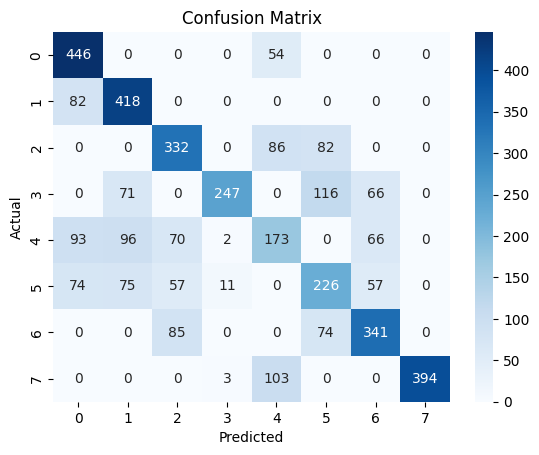

--------------------------------------------------  END  -------------------------------------------------- 



In [19]:
df = pd.read_csv(with_transformer_file_name)
zsl_classes, unseen_class = [], []

for _, row in df.iterrows():
    ActualClass = row['image_label']
    SimilarWords = eval(row['similar_wds'])[0]

    if ActualClass in SimilarWords:
        zsl_classes.append(words.index(ActualClass))
        unseen_class.append(words.index(ActualClass))
    else:
        zsl_classes.append(words.index(SimilarWords[0]))
        unseen_class.append(words.index(ActualClass))

df['ZSL Predicted Class'] = zsl_classes
df['ZSL Unseen Class'] = unseen_class
# display(df.head())

test_labels, pred_labels = df['ZSL Unseen Class'], df['ZSL Predicted Class']
evaluate_model(test_labels, pred_labels)

df.to_csv(with_transformer_file_name, index=False)
print('-'*50, ' END ', '-'*50, '\n')

In [26]:
# !zip -r archive_data_test.zip /content/data/test
# !zip -r archive_data_train.zip /content/data/train
# !zip -r archive_data_val.zip /content/data/val

In [27]:
# !zip archive_models.zip /content/classification_model.h5 /content/complete_xray_features.csv /content/min_max_scaler_file.pkl

In [28]:
# !zip -r archive_metadata.zip /content/metadata

In [39]:
img_path = r'/content/data/train/Atelectasis/00000999_000.png'
# Extract visual features using ResNet50
visual_features = extract_visual_features(img_path)
# Compute texture features using GLCM
texture_features = compute_texture_features(img_path)
# Concatenate visual and texture features
l1 = visual_features[0].tolist()
l2 = texture_features.tolist()
l1.extend(l2)
combined_features = np.array(l1)
# Normalize the features
train_normalized_texture_features = min_max_scaler_model.transform([combined_features])
train_normalized_texture_features_df = pd.DataFrame(train_normalized_texture_features)
# model predict
predicted_value = classification_model.predict(train_normalized_texture_features_df, verbose = 0)
print(predicted_value[0], max(predicted_value[0]))
print(f"predicted_value : {np.argmax(predicted_value)} || {class_labels[np.argmax(predicted_value)]}")

SentenceTransformer_model = SentenceTransformer('all-MiniLM-L6-v2')

# ['Atelectasis', 'Consolidation', 'Effusion', 'Hernia', 'Mass', 'No Finding', 'Pneumonia']
# ['Cardiomegaly', 'Edema', 'Emphysema', 'Fibrosis', 'Infiltration', 'Nodule', 'Pleural_Thickening', 'Pneumothorax']
image_class = ['Atelectasis', 'Consolidation', 'Effusion',
               'Hernia', 'Mass', 'No Finding', 'Pneumonia']
idx_to_class = {k: v for k, v in enumerate(image_class)}
words = list(idx_to_class.values())
embeddings = SentenceTransformer_model.encode(words, convert_to_tensor=True)
# Find top n similar
query = SentenceTransformer_model.encode(class_labels[np.argmax(predicted_value)], convert_to_tensor=True)
cosine_scores = util.cos_sim(query, embeddings)
# Show top-3 results
top_results = torch.topk(cosine_scores[0], k=5)
for idx in top_results.indices:
    print(words[idx], float(cosine_scores[0][idx]))

print('-'*50, ' SEEN ', '-'*50, '\n')

image_class = ['Cardiomegaly', 'Edema', 'Emphysema', 'Fibrosis',
               'Infiltration', 'Nodule', 'Pleural_Thickening', 'Pneumothorax']
idx_to_class = {k: v for k, v in enumerate(image_class)}
words = list(idx_to_class.values())
embeddings = SentenceTransformer_model.encode(words, convert_to_tensor=True)
# Find top n similar
query = SentenceTransformer_model.encode(class_labels[np.argmax(predicted_value)], convert_to_tensor=True)
cosine_scores = util.cos_sim(query, embeddings)
# Show top-3 results
top_results = torch.topk(cosine_scores[0], k=5)
for idx in top_results.indices:
    print(words[idx], float(cosine_scores[0][idx]))

print('-'*50, ' UNSEEN ', '-'*50, '\n')

[9.9434447e-01 2.2773263e-03 5.1740487e-04 2.9578294e-05 1.3085893e-05
 1.1611612e-04 2.7020231e-03] 0.9943445
predicted_value : 0 || Cardiomegaly
Hernia 0.3452252745628357
Effusion 0.30664896965026855
Atelectasis 0.2700609564781189
Mass 0.23105835914611816
Pneumonia 0.18271493911743164
--------------------------------------------------  SEEN  -------------------------------------------------- 

Cardiomegaly 1.0
Fibrosis 0.33140113949775696
Pleural_Thickening 0.32545551657676697
Pneumothorax 0.3251130282878876
Emphysema 0.316808819770813
--------------------------------------------------  UNSEEN  -------------------------------------------------- 



In [1]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 62.2 MB/s eta 0:00:00


In [4]:
%%writefile app.py
from PIL import Image
import streamlit as st
import pandas as pd
import numpy as np
from keras.applications import ResNet50
from keras.applications.resnet50 import preprocess_input
from keras.models import load_model
from skimage.feature import graycomatrix, graycoprops
from pickle import load
from sentence_transformers import SentenceTransformer, util
import torch

# Function to extract visual features using ResNet50
def extract_visual_features(image_path, model):
    img = Image.open(image_path).convert("RGB")
    img = img.resize((224, 224))  # Resize image for ResNet50 input
    img_array = np.array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array = preprocess_input(img_array)
    visual_features = model.predict(img_array, verbose = 0)
    return visual_features

# Function to compute GLCM texture features
def compute_texture_features(image_path):
    distances = [1, 3, 5, 3, 1, 3, 5]
    angles = [0, 0, 0, np.pi/4, np.pi/2, np.pi/2, np.pi/2]
    glcm_features = []
    for distance, angle in list(zip(distances, angles)):
        img_gray = Image.open(image_path).convert('L')  # Convert image to grayscale
        img_gray_array = np.array(img_gray)
        glcm = graycomatrix(img_gray_array, distances=[distance], angles=[angle], levels=256, symmetric=True, normed=True)
        contrast = graycoprops(glcm, 'contrast')[0, 0]
        dissimilarity = graycoprops(glcm, 'dissimilarity')[0, 0]
        homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
        energy = graycoprops(glcm, 'energy')[0, 0]
        correlation = graycoprops(glcm, 'correlation')[0, 0]
        glcm_features.extend([contrast, dissimilarity, homogeneity, energy, correlation])
    return np.array(glcm_features)

# Streamlit app
def main():
    # Load models
    ResNet50_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')
    classification_model = load_model(r'classification_model.h5')
    min_max_scaler_model = load(open(r'min_max_scaler_file.pkl', 'rb'))
    SentenceTransformer_model = SentenceTransformer('all-MiniLM-L6-v2')
    seen_class_labels = ['Atelectasis', 'Consolidation', 'Effusion', 'Hernia', 'Mass', 'No Finding', 'Pneumonia']
    seen_idx_to_class = {k: v for k, v in enumerate(seen_class_labels)}
    seen_words = list(seen_idx_to_class.values())
    seen_embeddings = SentenceTransformer_model.encode(seen_words, convert_to_tensor=True)
    unseen_class_labels = ['Cardiomegaly', 'Edema', 'Emphysema', 'Fibrosis', 'Infiltration', 'Nodule', 'Pleural_Thickening', 'Pneumothorax']
    unseen_idx_to_class = {k: v for k, v in enumerate(unseen_class_labels)}
    unseen_words = list(unseen_idx_to_class.values())
    unseen_embeddings = SentenceTransformer_model.encode(unseen_words, convert_to_tensor=True)

    # Define the app
    st.title("Image Classification with Probability Visualization")
    uploaded_file = st.file_uploader("Upload an Image", type=["jpg","jpeg","png"])
    if uploaded_file is not None:
        st.image(uploaded_file, caption="Uploaded Image", use_column_width=True)
        visual_features = extract_visual_features(uploaded_file, ResNet50_model)
        texture_features = compute_texture_features(uploaded_file)
        l1 = visual_features[0].tolist()
        l2 = texture_features.tolist()
        l1.extend(l2)
        combined_features = np.array(l1)

        # Normalize the features #
        train_normalized_texture_features = min_max_scaler_model.transform([combined_features])
        train_normalized_texture_features_df = pd.DataFrame(train_normalized_texture_features)
        # model predict
        predicted_value = classification_model.predict(train_normalized_texture_features_df, verbose = 0)
        # st.write(f"predicted_value : {np.argmax(predicted_value)} || {seen_class_labels[np.argmax(predicted_value)]}")
        predicted_class = seen_class_labels[np.argmax(predicted_value)]
        confidence = max(predicted_value[0])
        # st.subheader(f"Predicted Class: **{predicted_class}**")
        # st.write(f"Confidence: **{confidence:.2f}**")

        # predicted_class = 'Hernia'
        # confidence = 0.89865
        st.subheader(f"Predicted Class: **{predicted_class}**")
        st.write(f"Confidence: **{(confidence*100):.2f} %**")

        if predicted_class != 'No Finding':
            seen_query = SentenceTransformer_model.encode(predicted_class, convert_to_tensor=True)
            seen_cosine_scores = util.cos_sim(seen_query, seen_embeddings)
            seen_top_results = torch.topk(seen_cosine_scores[0], k=5)
            seen_class_names, seen_probabilities = [], []
            for score, idx in zip(seen_top_results.values, seen_top_results.indices):
                seen_class_names.append(seen_class_labels[idx])
                seen_probabilities.append(float(f"{score:.2f}"))
            unseen_query = SentenceTransformer_model.encode(predicted_class, convert_to_tensor=True)
            unseen_cosine_scores = util.cos_sim(unseen_query, unseen_embeddings)
            unseen_top_results = torch.topk(unseen_cosine_scores[0], k=5)
            unseen_class_names, unseen_probabilities = [], []
            for score, idx in zip(unseen_top_results.values, unseen_top_results.indices):
                unseen_class_names.append(unseen_class_labels[idx])
                unseen_probabilities.append(float(f"{score:.2f}"))
            seen_data = pd.DataFrame({'Class': seen_class_names, 'Probability': seen_probabilities})
            unseen_data = pd.DataFrame({'Class': unseen_class_names, 'Probability': unseen_probabilities})
            col1, col2 = st.columns(2)
            with col1:
                st.header("From Seen")
                st.subheader("Prediction Probabilities")
                for _, row in seen_data.iterrows():
                    st.write(f"{row['Class']} : {(row['Probability']*100):.2f} %")
                    st.progress(float(row['Probability']))
            with col2:
                st.header("From Unseen")
                st.subheader("Prediction Probabilities")
                for _, row in unseen_data.iterrows():
                    st.write(f"{row['Class']} : {(row['Probability']*100):.2f} %")
                    st.progress(float(row['Probability']))

# Run the app
if __name__ == "__main__":
    main() # streamlit run your_app.py

Overwriting app.py


In [5]:
import urllib
print("Password/Enpoint IP for localtunnel is: ", urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip("\n"))

!npm install localtunnel
!streamlit run app.py & npx localtunnel --port 8501


Password/Enpoint IP for localtunnel is:  34.148.159.8
⠙⠹⠸⠼⠴⠦⠧⠇
up to date, audited 23 packages in 1s
⠇
⠇3 packages are looking for funding
⠇  run `npm fund` for details
⠇
2 high severity vulnerabilities

To address all issues (including breaking changes), run:
  npm audit fix --force

Run `npm audit` for details.
⠏⠙

your url is: https://pink-plums-listen.loca.lt

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.148.159.8:8501

2025-08-21 22:47:48.544006: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755816468.606481   56071 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755816468.620476   56071 cuda_blas.cc:1407] Unable to register 